In [2]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# You will import the specific sklearn modules you need inside each section.
# Example: from sklearn.model_selection import train_test_split

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)   # use this everywhere so your results are reproducible
np.random.seed(RANDOM_STATE)

print("Running on:", DEVICE)
     

Running on: cpu


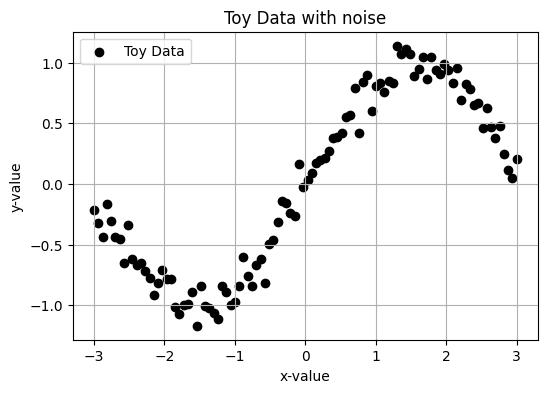

Initial w: -0.12804293524962831
Initial b: 0.1754794181984365


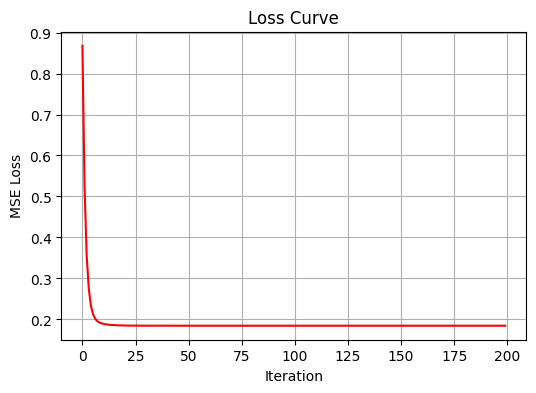

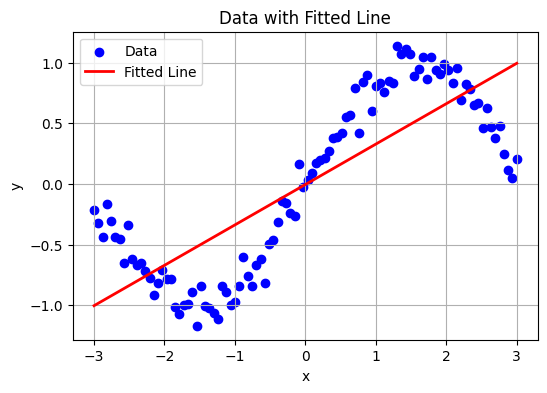

In [9]:
x = np.linspace(-3, 3, 100)
y = np.sin(x) + np.random.normal(0, 0.1, size=x.shape)

#ploting the data 
plt.figure(figsize=(6, 4))
plt.scatter(x, y, color='black', label='Toy Data')
plt.title("Toy Data with noise")
plt.xlabel("x-value")
plt.ylabel("y-value")
plt.legend()
plt.grid(True)
plt.show()


#Initialise w and b to small random values.
w = np.random.randn() * 0.1
b = np.random.randn() * 0.1

print("Initial w:", w)
print("Initial b:", b)

lr = 0.05
num_steps = 200
loss_history = []

for step in range(num_steps):

    # Forward pass
    y_hat = w * x + b

    # Compute loss
    loss = np.mean((y_hat - y) ** 2)
    loss_history.append(loss)

    # Compute gradients
    dw = np.mean(2 * (y_hat - y) * x)
    db = np.mean(2 * (y_hat - y))

    #Update parameters
    w = w - lr * dw
    b = b - lr * db

# TODO: Plot (a) the loss curve over the 200 steps, and
#             (b) the data with the fitted line on top.

# (a) Loss curve
plt.figure(figsize=(6, 4))
plt.plot(loss_history, color='red')
plt.title("Loss Curve")
plt.xlabel("Iteration")
plt.ylabel("MSE Loss")
plt.grid(True)
plt.show()

# (b) Data with fitted line
y_hat = w * x + b

plt.figure(figsize=(6, 4))
plt.scatter(x, y, color='blue', label='Data')
plt.plot(x, y_hat, color='red', linewidth=2, label='Fitted Line')
plt.title("Data with Fitted Line")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.show()





![Derivative](der.png) 
```python
dw = np.mean(2 * (y_hat - y) * x)
```

because `np.mean(...)` computes the average, which is equivalent ecause `np.mean(...)` computes the average, which is equivalent to

$$
\frac{1}{n}\sum.
$$



The model is underfitting.

A single neuron can only learn a linear relationship since its formula for pridicition is a straight line 

however the target function which is 
$$
\hat{y}=wx+b,
$$

which represents a straight line. However, the target function

$$
y=\sin(x)
$$

is non-linear and continuouslt curves up and down.No mattere how trained a model is , adjusting the weight (w) and bias (b) only changes the slope and the position of the line.it cannot produce the curved shape of a sine wave.

Initially, the loss decreases as the model identifies the best possible straight-line relationship. However, after a certain point, the loss stops improving because the model has reached the limits of its capacity. This demonstrates **underfitting**, where the model is too simple to effectively capture the true pattern present in the data.
